<a href="https://colab.research.google.com/github/B23BB1046/.github.io/blob/main/Lab_Transformer_En_Hi_Translation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Transformer-Based English to Hindi Translation

---

**Objective:** Build a small encoder-decoder Transformer for English-to-Hindi machine translation, understanding positional encoding, multi-head attention, masking, teacher forcing, and greedy decoding along the way.

<!-- **What you will learn:**
- Why self-attention replaces recurrence
- How positional encodings inject word-order information
- Scaled dot-product attention (from scratch in NumPy)
- The full encoder-decoder Transformer architecture (using PyTorch built-ins)
- Teacher forcing during training vs. auto-regressive decoding at inference
- How to visualize attention maps to interpret what the model learns

**Prerequisites:** Familiarity with PyTorch, RNNs/LSTMs, and the encoder-decoder framework. -->


---
## Part 1 : From RNNs to Transformers

Recall that recurrent networks process sequences **one token at a time**, maintaining a hidden state $h_t$ that compresses the past. This has two major limitations:

**1. Sequential bottleneck:** Since $h_t$ depends on $h_{t-1}$, we cannot parallelise across time steps. Training on long sequences is slow.

**2. Long-range forgetting:** Even LSTMs struggle when a word at position 3 must attend to a word at position 50. The information has to survive many sequential updates.

**3.** We cannot recover something which is lost.

The **Transformer** (Vaswani et al., 2017) solves both problems with **self-attention**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Every token directly attends to **every other token** in one operation, meaning:
- All positions are processed **in parallel** (GPU-friendly)
- Long-range dependencies are captured in a **single step**, not through a chain of hidden states

Let's build this up piece by piece.

---
## Part 0 : Setup

In [1]:
# Install a font that supports Devanagari script (for attention plots later)
!apt-get install -y -qq fonts-noto-core > /dev/null 2>&1

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import math, time, copy, random, os, zipfile, warnings, logging
from collections import Counter

# ---- Suppress noisy warnings ----
# PyTorch mask-type and nested-tensor warnings (via warnings module)
warnings.filterwarnings('ignore', message='.*mismatched key_padding_mask.*')
warnings.filterwarnings('ignore', message='.*nested tensors.*')
warnings.filterwarnings('ignore', message='.*Glyph.*missing from font.*')
warnings.filterwarnings('ignore', message='.*does not support.*natively.*')
# Matplotlib font warnings come through the logging module, not warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# ---- Configure Devanagari-capable font ----
# Clear stale cache and rebuild so newly installed fonts are detected
!rm -f ~/.cache/matplotlib/*.json
fm._load_fontmanager(try_read_cache=False)  #Reload Font Manager

# Auto-detect the correct registered name for Noto Sans Devanagari
# Loop through all fonts and keep only those where:
# Name contains "devanagari"
# AND name contains "noto
noto_dev = [f.name for f in fm.fontManager.ttflist
            if 'devanagari' in f.name.lower() and 'noto' in f.name.lower()]
if noto_dev:
    plt.rcParams['font.family'] = noto_dev[0]
    print(f"Devanagari font found: {noto_dev[0]}")
else:
    # Fallback: any Noto Sans that ships with the Noto package
    noto_any = [f.name for f in fm.fontManager.ttflist if 'Noto Sans' in f.name]
    if noto_any:
        plt.rcParams['font.family'] = noto_any[0]
        print(f"Fallback font: {noto_any[0]} (Devanagari may not render)")
    else:
        print("Warning: no Noto font found; Hindi labels may not render.")

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Part 2 : Loading a Real Parallel Corpus

### 2.1 The Tatoeba English-Hindi Dataset

We use the **Tatoeba** project's English-Hindi parallel corpus, hosted on [manythings.org](http://www.manythings.org/anki/). This is the same source used in PyTorch's official seq2seq tutorial. It contains thousands of crowd-sourced sentence pairs with natural, everyday language.


### 2.2 Download and Load

In [2]:
# Download the Tatoeba Hindi-English pairs
!wget -q http://www.manythings.org/anki/hin-eng.zip -O /tmp/hin-eng.zip

with zipfile.ZipFile('/tmp/hin-eng.zip') as z:
    with z.open('hin.txt') as f:
        raw_lines = f.read().decode('utf-8').strip().split('\n')

# Each line: English \t Hindi \t attribution
all_pairs = []
for line in raw_lines:
    parts = line.split('\t')
    if len(parts) >= 2:
        en = parts[0].strip().lower()
        hi = parts[1].strip()
        all_pairs.append((en, hi))

print(f"Total sentence pairs in corpus: {len(all_pairs):,}")
print(f"\nRaw samples (before filtering):")
for en, hi in all_pairs[:5]:
    print(f"  EN: {en:40s}  ->  HI: {hi}")

Total sentence pairs in corpus: 3,117

Raw samples (before filtering):
  EN: wow!                                      ->  HI: वाह!
  EN: duck!                                     ->  HI: झुको!
  EN: duck!                                     ->  HI: बतख़!
  EN: help!                                     ->  HI: बचाओ!
  EN: jump.                                     ->  HI: उछलो.


### 2.3 Filtering

<!-- A naive approach of "grab 1500 random short sentences" leads to a **sparse vocabulary problem**: ~2000 unique words where most appear only once. A tiny model cannot learn meaningful embeddings from single examples.

Instead, we use a smarter pipeline:
1. Filter for short sentences (3-8 words)
2. Count word frequencies across the entire filtered pool
3. Build vocabularies using only **frequent words** (appearing $\geq 3$ times)
4. Keep only sentence pairs where **every word** is in the vocabulary

This ensures the model sees each word many times during training, giving it a fair chance to learn. -->

Problems:
- Too many rare words
- Vocabulary Explosion

We want:

- Short sentences
- Frequent words only
- Dense vocabulary
- Manageable dataset size


In [11]:
MIN_WORDS = 3
MAX_WORDS = 8
MIN_FREQ = 3     # only keep words appearing at least this many times
MAX_PAIRS = 3000  # cap the final dataset size

# Step 1: Length filter
length_filtered = []
for en, hi in all_pairs:
    en_words = en.split()
    hi_words = hi.split()
    if (MIN_WORDS <= len(en_words) <= MAX_WORDS and
        MIN_WORDS <= len(hi_words) <= MAX_WORDS):
        length_filtered.append((en, hi))

print(f"After length filter (both {MIN_WORDS}-{MAX_WORDS} words): {len(length_filtered):,} pairs")

# Step 2: Count word frequencies
en_counter = Counter()
hi_counter = Counter()
for en, hi in length_filtered:
    en_counter.update(en.split())
    hi_counter.update(hi.split())

# Step 3: Build frequent-word sets
# If word appears once:
# Model cannot learn embedding
# Embedding becomes noise
# Cross-entropy loss becomes unstable
en_vocab_set = {w for w, c in en_counter.items() if c >= MIN_FREQ}
hi_vocab_set = {w for w, c in hi_counter.items() if c >= MIN_FREQ}
print(f"Frequent English words (freq >= {MIN_FREQ}): {len(en_vocab_set)}")
print(f"Frequent Hindi words (freq >= {MIN_FREQ}): {len(hi_vocab_set)}")

# Step 4: Keep only pairs where ALL words are frequent. If even one rare word exists → discard sentence.
clean_pairs = []
for en, hi in length_filtered:
    if (all(w in en_vocab_set for w in en.split()) and
        all(w in hi_vocab_set for w in hi.split())):
        clean_pairs.append((en, hi))

random.shuffle(clean_pairs)
pairs = clean_pairs[:MAX_PAIRS]

print(f"\nFinal clean pairs: {len(pairs)}")
print(f"\nSample pairs:")
for en, hi in pairs[:10]:
    print(f"  EN: {en:40s}  ->  HI: {hi}")

After length filter (both 3-8 words): 2,202 pairs
Frequent English words (freq >= 3): 719
Frequent Hindi words (freq >= 3): 746

Final clean pairs: 419

Sample pairs:
  EN: you may be right.                         ->  HI: तुम शायद सही हो।
  EN: it's a difficult problem.                 ->  HI: यह समस्या बहुत कठिन है।
  EN: he could not come because of his illness.  ->  HI: वह बीमारी की वजह से नहीं आ सका।
  EN: he looked up at the sky.                  ->  HI: उसने आसमान की तरफ़ देखा।
  EN: i had a letter from her yesterday.        ->  HI: मेरे पास कल उसकी एक चिट्ठी आई।
  EN: i can't make it this time.                ->  HI: मैं इस बार नहीं आ सकता।
  EN: this is a book.                           ->  HI: यह एक किताब है।
  EN: please give me a cup of tea.              ->  HI: मुझे एक कप चाय दीजिए।
  EN: he has long legs.                         ->  HI: उसके पैर लम्बे हैं।
  EN: i'd like to see him tomorrow afternoon.   ->  HI: मैं उससे कल दोपहर को मिलना चाहता हूँ।


<!-- Without this filtering:

Small Transformer would:

Overfit rare words

Fail to generalize

Produce unstable training curves

Filtering improves:

Signal-to-noise ratio. -->

---
## Part 3 : Tokenization and Vocabulary

### 3.1 The Idea

A Transformer operates on integer token IDs, not raw strings. We need to:

1. **Build a vocabulary** mapping each unique word to an integer.
2. **Add special tokens:**
   - `<pad>` (index 0) for padding shorter sentences to uniform length
   - `<sos>` (index 1) for Start Of Sequence, fed to the decoder at the first step
   - `<eos>` (index 2) for End Of Sequence, signals the model to stop generating
3. **Encode** each sentence as a list of token IDs.

We build **separate vocabularies** for English (source) and Hindi (target) since they have completely different scripts and word sets.

### 3.2 Implementation

In [12]:
# Special token indices (used throughout the notebook)
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2

class Vocabulary:
    """Simple word-level vocabulary with special tokens."""

    def __init__(self):
        self.word2idx = {'<pad>': PAD_IDX, '<sos>': SOS_IDX, '<eos>': EOS_IDX}
        self.idx2word = {PAD_IDX: '<pad>', SOS_IDX: '<sos>', EOS_IDX: '<eos>'}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

    def encode(self, sentence):
        """sentence string -> [SOS, w1, w2, ..., EOS]"""
        return [SOS_IDX] + [self.word2idx[w] for w in sentence.split()] + [EOS_IDX]

    def decode(self, ids):
        """list of token IDs -> sentence string (strips special tokens)"""
        words = []
        for idx in ids:
            if idx == EOS_IDX:
                break
            if idx not in (PAD_IDX, SOS_IDX):
                words.append(self.idx2word.get(idx, '<unk>'))
        return ' '.join(words)

    def __len__(self):
        return self.n_words


# Build vocabularies
src_vocab = Vocabulary()  # English
tgt_vocab = Vocabulary()  # Hindi

for en, hi in pairs:
    src_vocab.add_sentence(en)
    tgt_vocab.add_sentence(hi)

print(f"English vocabulary size : {len(src_vocab)}")
print(f"Hindi vocabulary size   : {len(tgt_vocab)}")

# Show word frequency stats for the final dataset
en_freq = Counter()
hi_freq = Counter()
for en, hi in pairs:
    en_freq.update(en.split())
    hi_freq.update(hi.split())
print(f"\nAvg occurrences per English word: {np.mean(list(en_freq.values())):.1f}")
print(f"Avg occurrences per Hindi word:   {np.mean(list(hi_freq.values())):.1f}")

print(f"\nEncoding example:")
ex_en, ex_hi = pairs[0]
print(f"  EN: '{ex_en}' -> {src_vocab.encode(ex_en)}")
print(f"  HI: '{ex_hi}' -> {tgt_vocab.encode(ex_hi)}")
print(f"  Decoded back: '{tgt_vocab.decode(tgt_vocab.encode(ex_hi))}'")

English vocabulary size : 470
Hindi vocabulary size   : 481

Avg occurrences per English word: 4.4
Avg occurrences per Hindi word:   4.8

Encoding example:
  EN: 'you may be right.' -> [1, 3, 4, 5, 6, 2]
  HI: 'तुम शायद सही हो।' -> [1, 3, 4, 5, 6, 2]
  Decoded back: 'तुम शायद सही हो।'


### 3.3 PyTorch Dataset and DataLoader

We pad all sentences to the same length within each batch so they can be stacked into tensors. The **padding mask** tells the Transformer to ignore `<pad>` positions.

In [13]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, hi = self.pairs[idx]
        return torch.LongTensor(self.src_vocab.encode(en)), \
               torch.LongTensor(self.tgt_vocab.encode(hi))

#We pad to max length inside the batch, not global max length.
def collate_fn(batch):
    """Pad source and target to the max length in the batch."""
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded



# Train / Val split (90% / 10%)
split = int(0.9 * len(pairs))
train_pairs = pairs[:split]
val_pairs = pairs[split:]

BATCH_SIZE = 64
train_loader = DataLoader(TranslationDataset(train_pairs, src_vocab, tgt_vocab),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(TranslationDataset(val_pairs, src_vocab, tgt_vocab),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_pairs)} pairs, Val: {len(val_pairs)} pairs")

# Quick sanity check
src_sample, tgt_sample = next(iter(train_loader))
print(f"Batch shapes: src={src_sample.shape}, tgt={tgt_sample.shape}")

Train: 377 pairs, Val: 42 pairs
Batch shapes: src=torch.Size([64, 10]), tgt=torch.Size([64, 10])


---
## Part 4 : Positional Encoding

### 4.1 The Problem

Self-attention is **permutation-invariant**: it treats "I am happy" the same as "happy am I". Word order carries crucial meaning, so we must inject it explicitly.



### 4.2 The Math

The original Transformer uses **sinusoidal positional encodings**. For position $pos$ and dimension $i$:

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \quad PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Why Sin/Cos?

- Unique for each position

- Allows model to extrapolate to longer sequences

- Relative position info is preserved

Each position gets a **unique fingerprint** vector. Low dimensions oscillate fast (fine position), high dimensions oscillate slowly (coarse position).

### 4.3 Implementation and Visualization

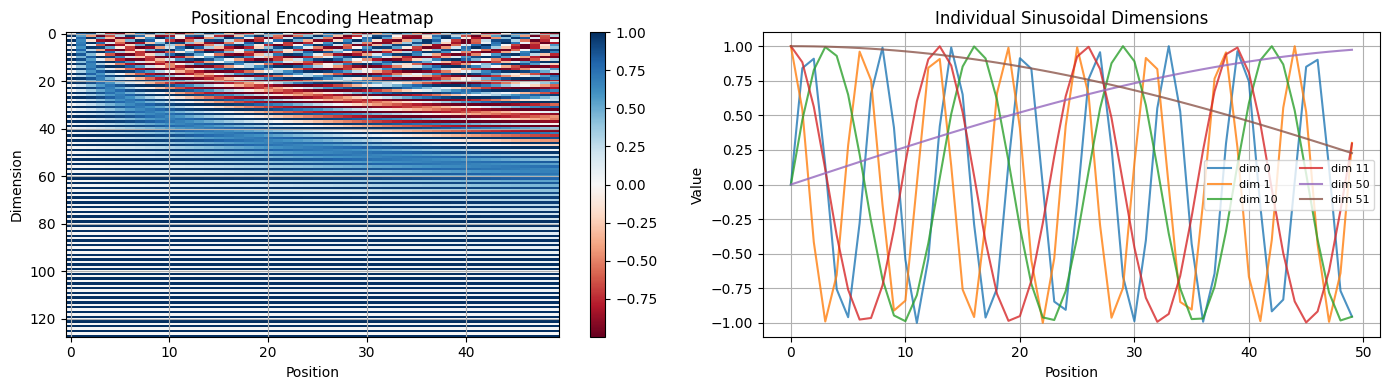

In [14]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (precomputed, not learned)."""

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


# Visualize the sinusoidal patterns
pe_viz = PositionalEncoding(d_model=128, dropout=0.0)
pe_values = pe_viz.pe[0, :50, :].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

im = ax1.imshow(pe_values.T, aspect='auto', cmap='RdBu', interpolation='nearest')
ax1.set_xlabel('Position'); ax1.set_ylabel('Dimension')
ax1.set_title('Positional Encoding Heatmap')
plt.colorbar(im, ax=ax1)

for dim in [0, 1, 10, 11, 50, 51]:
    ax2.plot(pe_values[:, dim], label=f'dim {dim}', alpha=0.8)
ax2.set_xlabel('Position'); ax2.set_ylabel('Value')
ax2.set_title('Individual Sinusoidal Dimensions')
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout(); plt.show()

**Key takeaway:** High-frequency sinusoids (low dimensions) change rapidly across positions for fine-grained discrimination. Low-frequency sinusoids (high dimensions) vary slowly for coarse position. Together, every position gets a unique signature.

---
## Part 5 : Scaled Dot-Product Attention (From Scratch)

### 5.1 The Core Mechanism

Attention answers: *"For each token, how much should I focus on every other token?"*

Given **Queries** $Q$, **Keys** $K$, and **Values** $V$ (all derived from the input via learned linear projections):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Intuition:
- $QK^\top$ computes a **similarity score** between every pair of tokens
- $\sqrt{d_k}$ scaling prevents dot products from growing too large (which would saturate the softmax)
- Softmax converts scores to **attention weights** (they sum to 1 per row)
- Multiplying by $V$ produces a **weighted combination** of value vectors

This is the one component we implement from scratch in NumPy, since understanding it deeply is essential.

### 5.2 NumPy Implementation

In [7]:
def scaled_dot_product_attention_numpy(Q, K, V, mask=None):
    """
    Pure NumPy implementation of scaled dot-product attention.

    Args:
        Q: (seq_q, d_k)  K: (seq_k, d_k)  V: (seq_k, d_v)
        mask: (seq_q, seq_k) boolean, True = block that position
    Returns:
        output:  (seq_q, d_v)
        weights: (seq_q, seq_k)
    """
    d_k = Q.shape[-1]

    # Step 1: raw attention scores
    scores = Q @ K.T / np.sqrt(d_k)

    # Step 2: mask future positions (if provided)
    if mask is not None:
        scores = np.where(mask, -1e9, scores)

    # Step 3: softmax (with numerical stability trick)
    exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))
    weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)

    # Step 4: weighted sum of values
    output = weights @ V
    return output, weights


# Demo: 4 tokens, d_k = 8
np.random.seed(42)
seq_len, d_k = 4, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

output, weights = scaled_dot_product_attention_numpy(Q, K, V)

print("Attention weights (each row sums to 1):")
print(np.round(weights, 3))
print(f"Row sums: {weights.sum(axis=-1).round(6)}")

Attention weights (each row sums to 1):
[[0.084 0.255 0.515 0.145]
 [0.641 0.133 0.017 0.209]
 [0.47  0.088 0.111 0.331]
 [0.178 0.492 0.201 0.13 ]]
Row sums: [1. 1. 1. 1.]


### 5.3 The Causal (Look-Ahead) Mask

In the **decoder**, when predicting token $t$, the model must not peek at tokens $t+1, t+2, \ldots$ It can only attend to the **past**. We enforce this with a **causal mask**: an upper-triangular matrix that blocks future positions.

$$\text{mask}[i, j] = \begin{cases} \text{True (block)} & \text{if } j > i \\ \text{False (allow)} & \text{otherwise} \end{cases}$$

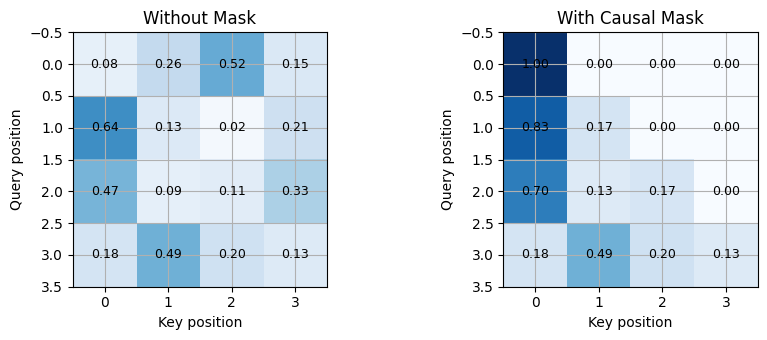

With the causal mask, each row only attends to current and previous positions.
Token 0 can only see itself. Token 3 can see all 4 tokens.


In [8]:
causal_mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
_, weights_masked = scaled_dot_product_attention_numpy(Q, K, V, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, w, title in zip(axes, [weights, weights_masked],
                         ['Without Mask', 'With Causal Mask']):
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xlabel('Key position'); ax.set_ylabel('Query position')
    ax.set_title(title)
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{w[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print("With the causal mask, each row only attends to current and previous positions.")
print("Token 0 can only see itself. Token 3 can see all 4 tokens.")

---
## Part 6 : Multi-Head Attention

A single attention head learns **one** kind of similarity. But language has many types of relationships (syntactic, semantic, positional, etc). **Multi-head attention** runs $h$ attention heads in parallel, each with its own learned projections:


Example sentence:

The smart student who studied hard passed the exam easily.

Different relationships exist:

- student ↔ studied (subject relation)

- passed ↔ exam (object relation)

- smart ↔ student (attribute relation)


$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$
$$\text{MultiHead}(Q, K, V) = [\text{head}_1 \;; \ldots \;; \text{head}_h]\, W^O$$

If $d_{\text{model}} = 128$ and $h = 4$, each head operates on $d_k = 32$ dimensions. The total computation is roughly the same as a single full-dimension attention.

Each encoder/decoder layer also includes:
- **Residual connections:** $\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$
- **Feed-forward network:** $\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$

We will use PyTorch's built-in `nn.Transformer` which packages all of this together.

---
## Part 7 : The Complete Transformer Model

### 7.1 Architecture Overview

```
English tokens -> [Src Embedding + Pos Enc] -> Encoder (N layers) -> Memory
                                                                       |
Hindi tokens   -> [Tgt Embedding + Pos Enc] -> Decoder (N layers) -> Linear -> Softmax -> Hindi words
```

The **encoder** uses self-attention over the source (English) sentence. The **decoder** uses masked self-attention over the target tokens generated so far, plus cross-attention over the encoder output. A final linear layer projects to the Hindi vocabulary.

We wrap PyTorch's `nn.Transformer` with our own embedding layers, positional encoding, and output head.

### 7.2 Implementation

In [9]:
class TransformerTranslator(nn.Module):
    """
    Encoder-Decoder Transformer for sequence-to-sequence translation.
    Uses nn.Transformer internally with custom embeddings and output projection.
    """

    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=128, nhead=4, num_encoder_layers=3,
                 num_decoder_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        # Embeddings + positional encoding
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        # Transformer core (handles multi-head attention, FFN, residuals, layer norm)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )

        # Output projection to target vocabulary
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, tgt_mask=None,
                src_key_padding_mask=None, tgt_key_padding_mask=None):
        # Embed + scale + add positional encoding
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt) * math.sqrt(self.d_model))

        output = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.fc_out(output)  # (batch, tgt_len, tgt_vocab_size)


# Instantiate
model = TransformerTranslator(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=128, nhead=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=256,
    dropout=0.15,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"\n{model}")

Trainable parameters: 1,178,081

TransformerTranslator(
  (src_embedding): Embedding(470, 128, padding_idx=0)
  (tgt_embedding): Embedding(481, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.15, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.15, inplace=False)
          (dropout2): Dropout(p=0.15, inplace=False)
   

---
## Part 8 : Training with Teacher Forcing

### 8.1 What is Teacher Forcing?

During training, the decoder receives the **ground-truth** previous tokens as input, not its own predictions. This stabilises learning.

If the target is `<sos> A B C <eos>`:
- **Decoder input:** `<sos> A B C` (everything except the last token)
- **Labels:** `A B C <eos>` (everything except the first)

The decoder learns to predict the next token at every position simultaneously.

### 8.2 Training Loop

In [10]:
EPOCHS = 80
LR = 5e-4

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader), pct_start=0.15
)


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input  = tgt[:, :-1]  # decoder input (drop last)
        tgt_labels = tgt[:, 1:]   # labels (drop first)

        # Generate masks
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt_input == PAD_IDX)

        logits = model(src, tgt_input, tgt_mask=tgt_mask,
                       src_key_padding_mask=src_pad_mask,
                       tgt_key_padding_mask=tgt_pad_mask)

        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_labels.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input, tgt_labels = tgt[:, :-1], tgt[:, 1:]
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt_input == PAD_IDX)

        logits = model(src, tgt_input, tgt_mask=tgt_mask,
                       src_key_padding_mask=src_pad_mask,
                       tgt_key_padding_mask=tgt_pad_mask)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_labels.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)


# Train
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10}")
print('-' * 35)

for epoch in range(1, EPOCHS + 1):
    t_loss = train_one_epoch(model, train_loader)
    v_loss = evaluate(model, val_loader)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:5d} | {t_loss:10.4f} | {v_loss:10.4f}")

model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch | Train Loss |   Val Loss
-----------------------------------
    1 |     6.2925 |     6.1957
   10 |     5.1910 |     5.1809
   20 |     4.3331 |     4.6738
   30 |     3.7850 |     4.4383
   40 |     3.3776 |     4.2797
   50 |     3.1084 |     4.2002
   60 |     2.9480 |     4.1536
   70 |     2.8804 |     4.1452
   80 |     2.8615 |     4.1452

Best validation loss: 4.1446


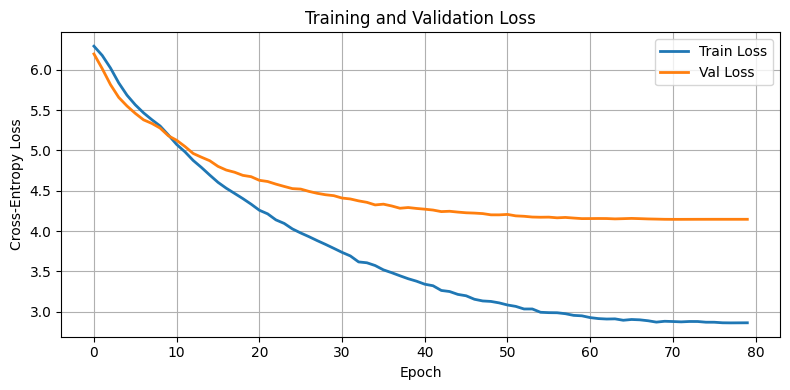

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

---
## Part 9 : Greedy Decoding (Inference)

### 9.1 How Auto-Regressive Decoding Works

At inference time, we don't have the ground-truth Hindi sentence. We generate one token at a time:

1. Encode the English sentence through the **encoder** to get memory.
2. Start the decoder with just `<sos>`.
3. Predict the next token (argmax of output logits = **greedy** decoding).
4. Append the predicted token to the decoder input.
5. Repeat until `<eos>` is produced or max length is reached.

### 9.2 Implementation

In [20]:
@torch.no_grad()
def translate_beam(model, sentence, src_vocab, tgt_vocab, max_len=30, beam_width=3):
    model.eval()

    # Encode source
    src_ids = src_vocab.encode(sentence)
    src = torch.LongTensor([src_ids]).to(device)
    src_pad_mask = (src == PAD_IDX)

    src_emb = model.pos_encoder(model.src_embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_pad_mask)

    # Beam structure: (sequence, score)
    beams = [([SOS_IDX], 0.0)]

    for _ in range(max_len):
        new_beams = []

        for seq, score in beams:
            if seq[-1] == EOS_IDX:
                new_beams.append((seq, score))
                continue

            tgt = torch.LongTensor([seq]).to(device)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(len(seq)).to(device)
            tgt_emb = model.pos_encoder(model.tgt_embedding(tgt) * math.sqrt(model.d_model))

            out = model.transformer.decoder(
                tgt_emb, memory,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_pad_mask
            )

            logits = model.fc_out(out[:, -1, :])
            log_probs = torch.log_softmax(logits, dim=-1)

            topk_probs, topk_ids = torch.topk(log_probs, beam_width)

            for k in range(beam_width):
                next_seq = seq + [topk_ids[0, k].item()]
                next_score = score + topk_probs[0, k].item()
                new_beams.append((next_seq, next_score))

        # Keep best beam_width sequences
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        # If all beams ended with EOS → stop early
        if all(seq[-1] == EOS_IDX for seq, _ in beams):
            break

    best_seq = beams[0][0]
    return tgt_vocab.decode(best_seq), best_seq

### 9.3 Evaluate on Training and Validation Data

In [21]:
def evaluate_pairs(pairs, label="Train", n=20):
    print(f"\n{'=' * 110}")
    print(f"  {label} Set Translations")
    print(f"{'=' * 110}")
    correct = 0
    for en, hi in pairs[:n]:
        pred, _ = translate(model, en, src_vocab, tgt_vocab)
        match = pred.strip() == hi.strip()
        correct += match
        flag = 'OK' if match else 'XX'
        print(f"  [{flag}] {en:35s} -> {pred:35s} (ref: {hi})")
    print(f"\n  Exact match: {correct}/{min(n, len(pairs))}")

evaluate_pairs(train_pairs, "Train", n=25)
evaluate_pairs(val_pairs, "Validation", n=25)


  Train Set Translations
  [XX] you may be right.                   -> ज़्यादा साफ़ महंगी तू यह            (ref: तुम शायद सही हो।)
  [XX] it's a difficult problem.           -> वजह बहुत जा वह की                   (ref: यह समस्या बहुत कठिन है।)
  [XX] he could not come because of his illness. -> समस्या बहुत वह आराम वह की           (ref: वह बीमारी की वजह से नहीं आ सका।)
  [XX] he looked up at the sky.            -> समस्या वह आराम वह आसमान             (ref: उसने आसमान की तरफ़ देखा।)
  [XX] i had a letter from her yesterday.  -> कल तो महंगी तू है! आई। समय एक       (ref: मेरे पास कल उसकी एक चिट्ठी आई।)
  [XX] i can't make it this time.          -> नहीं बार सकता। किताब                (ref: मैं इस बार नहीं आ सकता।)
  [XX] this is a book.                     -> होगा। अपना अपना की                  (ref: यह एक किताब है।)
  [XX] please give me a cup of tea.        -> वजह नहीं पास आपके समस्या सपना की    (ref: मुझे एक कप चाय दीजिए।)
  [XX] he has long legs.                   -> वजह बहुत क्यों कैसे

---
## Part 10 : Visualizing Cross-Attention

One of the Transformer's strengths is **interpretability**. We can inspect the cross-attention weights (where decoder queries attend to encoder keys) to see which source words the model focuses on when generating each target word.

In [18]:
@torch.no_grad()
def translate_with_attention(model, sentence, src_vocab, tgt_vocab, max_len=30):
    """Translate and capture cross-attention weights from the last decoder layer."""
    model.eval()

    src_ids = src_vocab.encode(sentence)
    src = torch.LongTensor([src_ids]).to(device)
    src_pad_mask = (src == PAD_IDX)

    src_emb = model.pos_encoder(model.src_embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_pad_mask)

    tgt_ids = [SOS_IDX]
    attn_weights_all = []

    for _ in range(max_len):
        tgt = torch.LongTensor([tgt_ids]).to(device)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(len(tgt_ids)).to(device)
        tgt_emb = model.pos_encoder(model.tgt_embedding(tgt) * math.sqrt(model.d_model))

        # Run through decoder layers manually to capture cross-attention
        output = tgt_emb
        for layer in model.transformer.decoder.layers:
            # Self-attention
            sa_out = layer.self_attn(output, output, output, attn_mask=tgt_mask)[0]
            output = layer.norm1(output + layer.dropout1(sa_out))
            # Cross-attention (capture weights here)
            ca_out, attn_w = layer.multihead_attn(
                output, memory, memory,
                key_padding_mask=src_pad_mask,
                need_weights=True, average_attn_weights=True,
            )
            output = layer.norm2(output + layer.dropout2(ca_out))
            # Feed-forward
            ff_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(output))))
            output = layer.norm3(output + layer.dropout3(ff_out))

        attn_weights_all.append(attn_w[0, -1, :].cpu().numpy())

        next_token = model.fc_out(output[:, -1, :]).argmax(dim=-1).item()
        tgt_ids.append(next_token)
        if next_token == EOS_IDX:
            break

    return tgt_ids, np.array(attn_weights_all), src_ids


def plot_attention(src_ids, tgt_ids, attn_matrix, src_vocab, tgt_vocab, title=""):
    """Heatmap of cross-attention weights."""
    src_tokens = [src_vocab.idx2word[i] for i in src_ids]
    tgt_tokens = [tgt_vocab.idx2word[i] for i in tgt_ids[1:]]  # skip leading <sos>

    fig, ax = plt.subplots(figsize=(max(5, len(src_tokens)*0.8),
                                     max(3, len(tgt_tokens)*0.6)))
    im = ax.imshow(attn_matrix, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=10)
    ax.set_xlabel('Source (English)'); ax.set_ylabel('Target (Hindi)')
    if title: ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

EN: you may be right.  ->  HI: ज़्यादा साफ़ महंगी तू यह


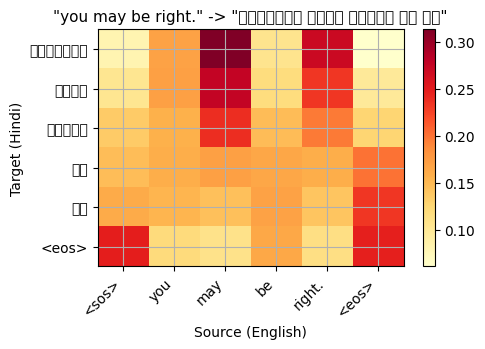

EN: it's a difficult problem.  ->  HI: वजह पढ़ बारी की


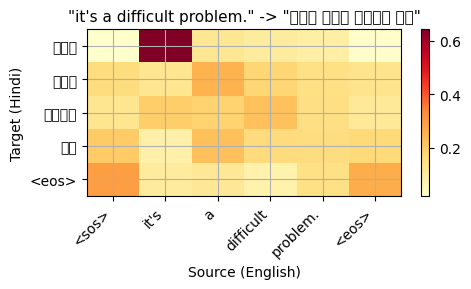

EN: he could not come because of his illness.  ->  HI: समस्या बहुत वह आराम वह की


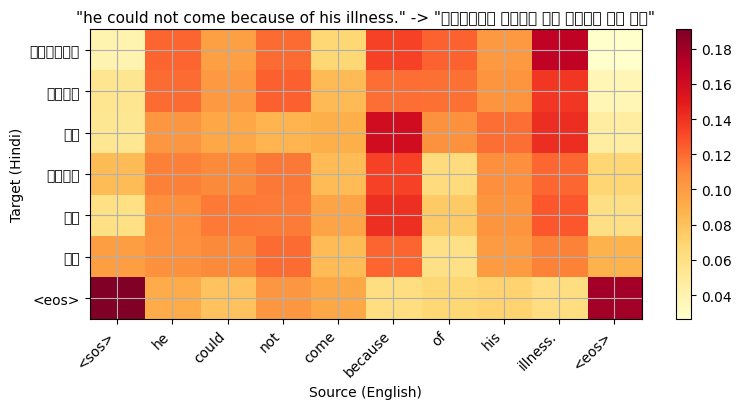

EN: he looked up at the sky.  ->  HI: समस्या देखा। वह आराम वह आसमान


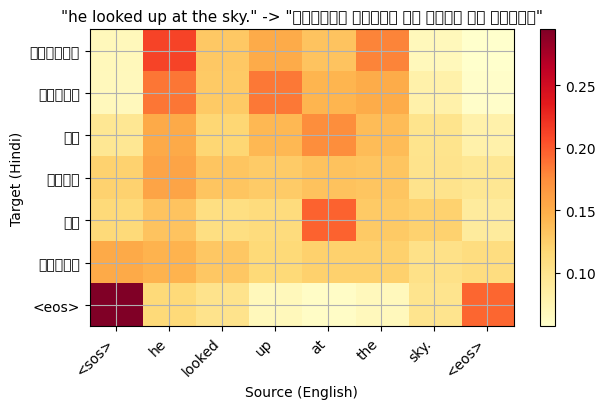

In [19]:
# Pick a few training examples to visualize attention
for en, hi in train_pairs[:4]:
    tgt_ids, attn_matrix, src_ids = translate_with_attention(model, en, src_vocab, tgt_vocab)
    pred = tgt_vocab.decode(tgt_ids)
    print(f"EN: {en}  ->  HI: {pred}")
    plot_attention(src_ids, tgt_ids, attn_matrix, src_vocab, tgt_vocab,
                   title=f'"{en}" -> "{pred}"')

**Key takeaway:** The attention maps reveal the model's learned **word alignments** between English and Hindi. When generating a Hindi word, the model ideally attends strongly to the corresponding English word(s). This interpretability is a major advantage of the Transformer over black-box RNN encoders.

---
## Part 11 : Exercises and Further Reading

### Exercises

1. **Beam search:** Replace greedy decoding with beam search (beam width = 3). Does it produce different or better translations for any sentences?

2. **Scale up the data:** Increase `MAX_PAIRS` to 5000+ and lower `MIN_FREQ` to 3. Re-train and measure how validation accuracy changes

2. **Reduce Frequency:** Keep `MAX_PAIRS` same as 3000 and lower `MIN_FREQ` to 1. Re-train and measure how validation accuracy changes


4. **BPE tokenization:** Replace word-level tokenization with a subword tokenizer (e.g., `sentencepiece`). How does this affect vocabulary size and translation quality?


### Further Reading

| Resource | Link |
|---|---|
| Attention Is All You Need (Vaswani et al., 2017) | [arxiv.org/abs/1706.03762](https://arxiv.org/abs/1706.03762) |
| The Illustrated Transformer (Jay Alammar) | [jalammar.github.io/illustrated-transformer](https://jalammar.github.io/illustrated-transformer/) |
| The Annotated Transformer (Harvard NLP) | [nlp.seas.harvard.edu/annotated-transformer](https://nlp.seas.harvard.edu/annotated-transformer/) |
| PyTorch Seq2Seq Translation Tutorial | [pytorch.org/tutorials](https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html) |
| Lilian Weng's Attention blog | [lilianweng.github.io](https://lilianweng.github.io/posts/2018-06-24-attention/) |

---

### Summary

| What we covered | Key insight |
|---|---|
| **Self-attention** | Every token attends to every other token in parallel, replacing recurrence |
| **Positional encoding** | Sinusoidal patterns give each position a unique fingerprint; without them the model loses word order |
| **Causal masking** | The decoder can only attend to past tokens, preventing information leakage |
| **Multi-head attention** | Multiple parallel heads capture different relationship types |
| **Teacher forcing** | During training, the decoder sees ground-truth tokens; at inference, it uses its own predictions |
| **Greedy decoding** | One token at a time, always picking the highest-probability next token |
| **Attention visualization** | Cross-attention maps reveal learned word alignments between languages |




---